# 05 — Revenue Forecasting (optional advanced module)

Per the spec PDF, forecasting is explicitly an *optional, advanced* module, not the foundation of the project - included here because the user opted in. Reads `monthly_revenue_forecast`, populated by `src/forecasting.py` (Holt linear-trend exponential smoothing vs. a 3-month moving-average baseline).

Note: the dataset's first and last calendar months are partial (the 1-year history window starts and ends mid-month), so `src/forecasting.py` excludes both from the training series to avoid the trend model reacting to two artificial low points.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
from db import get_engine

engine = get_engine()
pd.options.display.float_format = '{:,.0f}'.format


## Actual vs. forecast

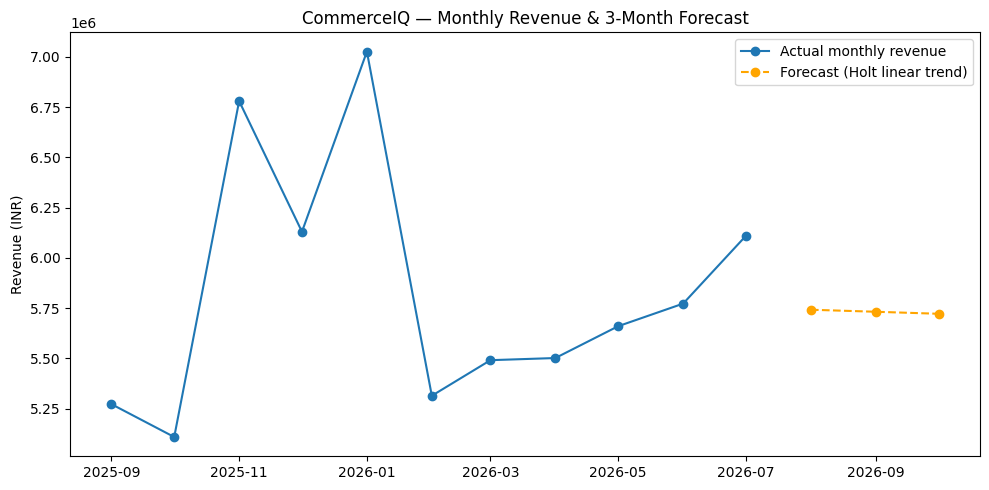

,forecast_month,forecast_revenue
11,2026-08-01,"5,742,592"
12,2026-09-01,"5,732,520"
13,2026-10-01,"5,722,447"


In [2]:
data = pd.read_sql('SELECT * FROM monthly_revenue_forecast ORDER BY forecast_month', engine)
actual = data[data['is_actual']]
forecast = data[~data['is_actual']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual['forecast_month'], actual['forecast_revenue'], marker='o', label='Actual monthly revenue')
ax.plot(forecast['forecast_month'], forecast['forecast_revenue'], marker='o', linestyle='--',
        color='orange', label='Forecast (Holt linear trend)')
ax.set_title('CommerceIQ — Monthly Revenue & 3-Month Forecast')
ax.set_ylabel('Revenue (INR)')
ax.legend()
plt.tight_layout()
plt.show()

forecast[['forecast_month', 'forecast_revenue']]


## Forecast vs. naive moving-average baseline

A forecast is only useful if it beats doing nothing. Here the 3-month moving average of the last actual months is compared to the model's first forecast month - they should be in the same ballpark for a low-trend series like this one, which is a reasonable sanity check.

In [3]:
baseline = actual['forecast_revenue'].tail(3).mean()
first_forecast = forecast.iloc[0]['forecast_revenue']
print(f"3-month moving-average baseline: INR {baseline:,.0f}")
print(f"Holt linear-trend forecast (next month): INR {first_forecast:,.0f}")
print(f"Difference: {abs(first_forecast - baseline) / baseline * 100:.1f}%")


3-month moving-average baseline: INR 5,848,072
Holt linear-trend forecast (next month): INR 5,742,592
Difference: 1.8%
